# Baseline Machine Learning Models

This notebook trains and evaluates four baseline classifiers for predicting Cesarean section delivery:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

All models use the same respondent-level train-test split and the preprocessing artifacts created in the previous notebook. The aim is to establish baseline performance before hyperparameter tuning and SHAP-based explainability.

## 1. Import Libraries

In [1]:
from pathlib import Path
from time import perf_counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

## 2. Load the Dataset and Preprocessing Artifacts

The cleaned modeling dataset, fitted preprocessors, transformed feature names, and saved train-test split are loaded from the previous phases.

In [2]:
possible_data_paths = [
    Path("../data/processed/df_model_v1.parquet"),
    Path("data/processed/df_model_v1.parquet")
]

data_path = next(
    (path for path in possible_data_paths if path.exists()),
    None
)

if data_path is None:
    raise FileNotFoundError("df_model_v1.parquet was not found.")

possible_artifact_paths = [
    Path("../artifacts"),
    Path("artifacts")
]

artifact_path = next(
    (path for path in possible_artifact_paths if path.exists()),
    None
)

if artifact_path is None:
    raise FileNotFoundError(
        "The artifacts folder was not found. Run the preprocessing notebook first."
    )

df_model = pd.read_parquet(data_path)

linear_preprocessor = joblib.load(
    artifact_path / "linear_preprocessor.joblib"
)

tree_preprocessor = joblib.load(
    artifact_path / "tree_preprocessor.joblib"
)

split_indices = pd.read_csv(
    artifact_path / "train_test_split_indices.csv"
)

transformed_feature_names = pd.read_csv(
    artifact_path / "transformed_feature_names.csv"
)["feature_name"].to_numpy()

print("Dataset shape:", df_model.shape)
print("Saved transformed features:", len(transformed_feature_names))
print("Artifact folder:", artifact_path.resolve())

Dataset shape: (201311, 49)
Saved transformed features: 99
Artifact folder: C:\IPD\IPD\artifacts


## 3. Reconstruct Predictors and Target

The same exclusions and predictor definitions used during preprocessing are recreated.

In [3]:
candidate_excluded_columns = [
    "respondent_id",
    "birth_index",
    "cluster_number",
    "household_number",
    "respondent_line_number",
    "sample_weight",
    "primary_sampling_unit",
    "sample_stratum_v022",
    "sample_stratum_v023",
    "state",
    "district",
    "delivery_place_code",
    "survey_weight",
    "csection"
]

excluded_columns = [
    column
    for column in candidate_excluded_columns
    if column in df_model.columns
]

X = df_model.drop(columns=excluded_columns).copy()

y = pd.to_numeric(
    df_model["csection"],
    errors="raise"
).astype(int)

print("Predictor matrix shape:", X.shape)
print("Target shape:", y.shape)

Predictor matrix shape: (201311, 36)
Target shape: (201311,)


## 4. Define Feature Groups and Convert Data Types

The same feature groups and scikit-learn-compatible type conversion used during preprocessing are applied again.

In [4]:
numeric_features = [
    "maternal_age",
    "education_years",
    "wealth_index",
    "birth_order",
    "total_children_ever_born",
    "preceding_birth_interval",
    "age_at_first_birth",
    "bmi",
    "first_anc_timing",
    "anc_visits"
]

categorical_features = [
    "facility_type",
    "residence",
    "religion",
    "social_group",
    "twin_order"
]

binary_features = [
    "health_insurance",
    "anc_doctor",
    "anc_nurse_midwife",
    "anc_traditional_attendant",
    "anc_community_worker",
    "anc_anganwadi_worker",
    "anc_asha_worker",
    "anc_other_provider",
    "no_anc_provider",
    "weight_measured_during_pregnancy",
    "bp_measured_during_pregnancy",
    "urine_sample_during_pregnancy",
    "blood_sample_during_pregnancy",
    "told_about_pregnancy_complications",
    "counselled_vaginal_bleeding",
    "counselled_convulsions",
    "counselled_prolonged_labour",
    "counselled_severe_abdominal_pain",
    "counselled_high_blood_pressure",
    "convulsions_during_pregnancy",
    "swelling_during_pregnancy"
]


def create_sklearn_compatible_frame(data):
    converted = pd.DataFrame(index=data.index)

    for feature in numeric_features:
        converted[feature] = (
            pd.to_numeric(
                data[feature],
                errors="coerce"
            )
            .to_numpy(
                dtype=np.float64,
                na_value=np.nan
            )
        )

    for feature in categorical_features + binary_features:
        converted[feature] = (
            data[feature]
            .astype("string")
            .fillna("Missing")
            .to_numpy(dtype=str)
        )

    return converted[data.columns]


X = create_sklearn_compatible_frame(X)

print("Converted data types:")
display(X.dtypes.value_counts())

Converted data types:


str        26
float64    10
Name: count, dtype: int64

## 5. Recreate the Saved Train-Test Split

The exact split created during preprocessing is reused so that every model is evaluated on the same unseen respondents.

In [5]:
if len(split_indices) != len(df_model):
    raise ValueError(
        "The saved split file does not match the dataset length."
    )

split_indices = split_indices.sort_values(
    "row_index"
).reset_index(drop=True)

if not np.array_equal(
    split_indices["row_index"].to_numpy(),
    df_model.index.to_numpy()
):
    raise ValueError(
        "The saved split indices do not match the dataset."
    )

train_mask = split_indices["split"].eq("train").to_numpy()
test_mask = split_indices["split"].eq("test").to_numpy()

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("Training predictors:", X_train.shape)
print("Test predictors:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

split_summary = pd.DataFrame({
    "training_percent": (
        y_train.value_counts(normalize=True)
        .sort_index()
        .mul(100)
    ),
    "test_percent": (
        y_test.value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )
}).round(2)

split_summary.index = [
    "Vaginal delivery",
    "Cesarean section"
]

display(split_summary)

Training predictors: (161048, 36)
Test predictors: (40263, 36)
Training target: (161048,)
Test target: (40263,)


,training_percent,test_percent
Vaginal delivery,77.77,77.77
Cesarean section,22.23,22.23


## 6. Apply the Saved Preprocessing Pipelines

The linear preprocessor produces scaled features for Logistic Regression. The tree preprocessor produces unscaled features for Decision Tree, Random Forest, and XGBoost.

In [6]:
X_train_linear = linear_preprocessor.transform(X_train)
X_test_linear = linear_preprocessor.transform(X_test)

X_train_tree = tree_preprocessor.transform(X_train)
X_test_tree = tree_preprocessor.transform(X_test)

print("Linear training shape:", X_train_linear.shape)
print("Linear test shape:", X_test_linear.shape)
print("Tree training shape:", X_train_tree.shape)
print("Tree test shape:", X_test_tree.shape)

Linear training shape: (161048, 99)
Linear test shape: (40263, 99)
Tree training shape: (161048, 99)
Tree test shape: (40263, 99)


## 7. Define a Reusable Evaluation Function

Each model is evaluated using accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC, a classification report, and a confusion matrix.

In [7]:
model_results = []
fitted_models = {}
prediction_results = {}


def evaluate_model(
    model_name,
    model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
):
    start_time = perf_counter()

    model.fit(
        X_train_processed,
        y_train
    )

    training_time = perf_counter() - start_time

    y_pred = model.predict(
        X_test_processed
    )

    y_probability = model.predict_proba(
        X_test_processed
    )[:, 1]

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test,
            y_probability
        ),
        "pr_auc": average_precision_score(
            y_test,
            y_probability
        ),
        "training_time_seconds": training_time
    }

    model_results.append(results)
    fitted_models[model_name] = model

    prediction_results[model_name] = {
        "predictions": y_pred,
        "probabilities": y_probability
    }

    print(f"{model_name} Results")
    print("-" * 50)

    display(
        pd.DataFrame([results]).round(4)
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Vaginal delivery",
                "Cesarean section"
            ],
            zero_division=0
        )
    )

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=[
            "Vaginal",
            "Cesarean"
        ],
        values_format=",d"
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return model

## 8. Logistic Regression Baseline

Logistic Regression provides an interpretable linear baseline. Balanced class weights reduce the tendency to favor the majority vaginal-delivery class.

Logistic Regression Results
--------------------------------------------------


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,training_time_seconds
0,Logistic Regression,0.7383,0.4443,0.7071,0.5457,0.7943,0.5109,6.1139



Classification Report:
                  precision    recall  f1-score   support

Vaginal delivery       0.90      0.75      0.82     31314
Cesarean section       0.44      0.71      0.55      8949

        accuracy                           0.74     40263
       macro avg       0.67      0.73      0.68     40263
    weighted avg       0.80      0.74      0.76     40263



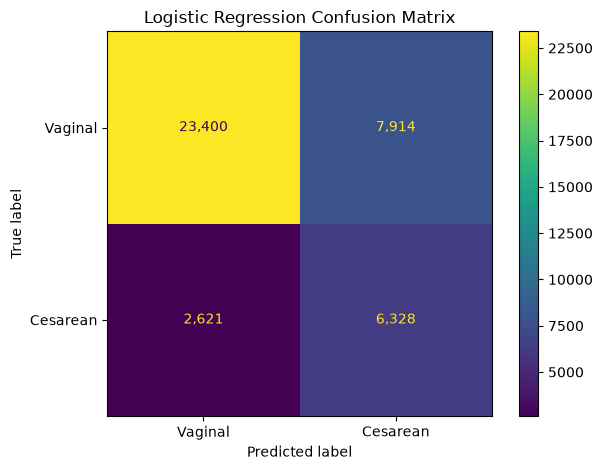

In [8]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

logistic_model = evaluate_model(
    model_name="Logistic Regression",
    model=logistic_model,
    X_train_processed=X_train_linear,
    X_test_processed=X_test_linear,
    y_train=y_train,
    y_test=y_test
)

## 9. Decision Tree Baseline

The Decision Tree can capture nonlinear patterns and feature interactions. This untuned model provides a simple tree-based baseline.

Decision Tree Results
--------------------------------------------------


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,training_time_seconds
0,Decision Tree,0.7229,0.378,0.3821,0.38,0.6012,0.2818,2.684



Classification Report:
                  precision    recall  f1-score   support

Vaginal delivery       0.82      0.82      0.82     31314
Cesarean section       0.38      0.38      0.38      8949

        accuracy                           0.72     40263
       macro avg       0.60      0.60      0.60     40263
    weighted avg       0.72      0.72      0.72     40263



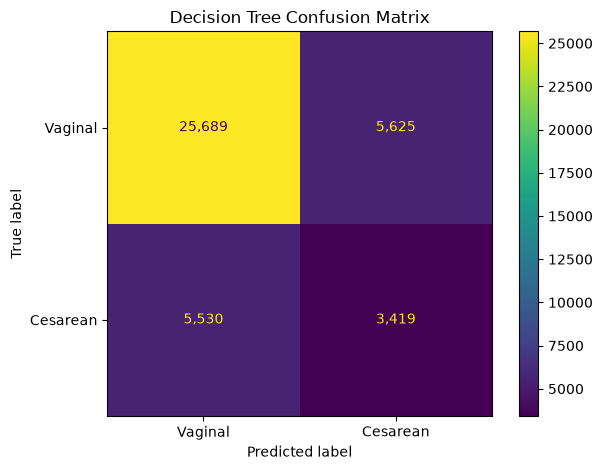

In [9]:
decision_tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

decision_tree_model = evaluate_model(
    model_name="Decision Tree",
    model=decision_tree_model,
    X_train_processed=X_train_tree,
    X_test_processed=X_test_tree,
    y_train=y_train,
    y_test=y_test
)

## 10. Random Forest Baseline

Random Forest combines many decision trees to improve stability and reduce the overfitting of a single tree.

Random Forest Results
--------------------------------------------------


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,training_time_seconds
0,Random Forest,0.7964,0.5866,0.2846,0.3833,0.7904,0.504,6.4624



Classification Report:
                  precision    recall  f1-score   support

Vaginal delivery       0.82      0.94      0.88     31314
Cesarean section       0.59      0.28      0.38      8949

        accuracy                           0.80     40263
       macro avg       0.70      0.61      0.63     40263
    weighted avg       0.77      0.80      0.77     40263



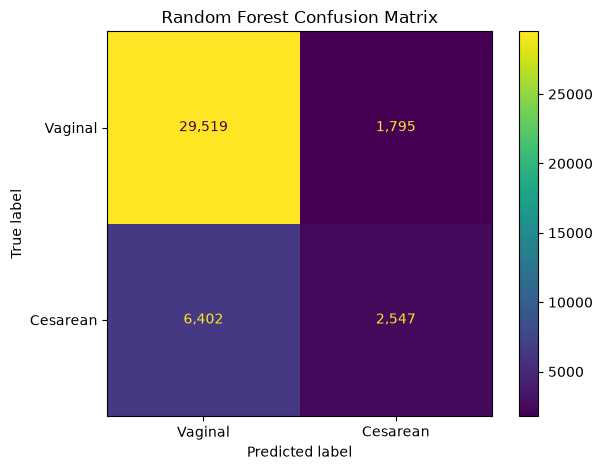

In [10]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

random_forest_model = evaluate_model(
    model_name="Random Forest",
    model=random_forest_model,
    X_train_processed=X_train_tree,
    X_test_processed=X_test_tree,
    y_train=y_train,
    y_test=y_test
)

## 11. XGBoost Baseline

XGBoost builds trees sequentially, with later trees correcting earlier errors. Class imbalance is handled using `scale_pos_weight`.

XGBoost scale_pos_weight: 3.499
XGBoost Results
--------------------------------------------------


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,training_time_seconds
0,XGBoost,0.7259,0.4325,0.7479,0.5481,0.8035,0.5333,3.7177



Classification Report:
                  precision    recall  f1-score   support

Vaginal delivery       0.91      0.72      0.80     31314
Cesarean section       0.43      0.75      0.55      8949

        accuracy                           0.73     40263
       macro avg       0.67      0.73      0.68     40263
    weighted avg       0.80      0.73      0.75     40263



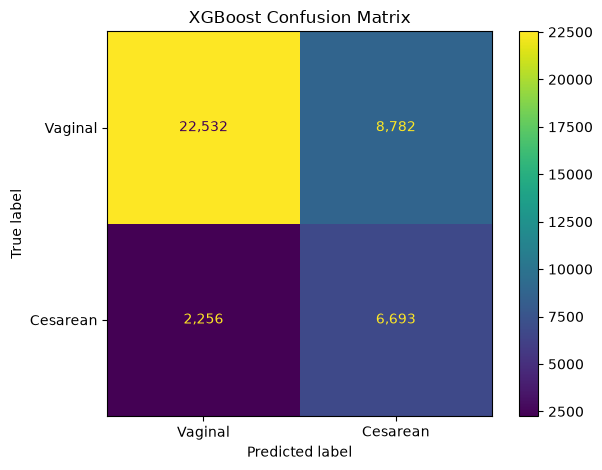

In [11]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = (
    negative_count
    / positive_count
)

print(
    "XGBoost scale_pos_weight:",
    round(scale_pos_weight, 3)
)

xgboost_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgboost_model = evaluate_model(
    model_name="XGBoost",
    model=xgboost_model,
    X_train_processed=X_train_tree,
    X_test_processed=X_test_tree,
    y_train=y_train,
    y_test=y_test
)

## 12. Compare Baseline Model Performance

All four models are compared using the same test set.

In [12]:
results_summary = (
    pd.DataFrame(model_results)
    .set_index("model")
    .sort_values(
        "roc_auc",
        ascending=False
    )
)

display(
    results_summary.round(4)
)

,accuracy,precision,recall,f1_score,roc_auc,pr_auc,training_time_seconds
model,,,,,,,
XGBoost,0.7259,0.4325,0.7479,0.5481,0.8035,0.5333,3.7177
Logistic Regression,0.7383,0.4443,0.7071,0.5457,0.7943,0.5109,6.1139
Random Forest,0.7964,0.5866,0.2846,0.3833,0.7904,0.5040,6.4624
Decision Tree,0.7229,0.3780,0.3821,0.3800,0.6012,0.2818,2.6840


## 13. Compare ROC Curves

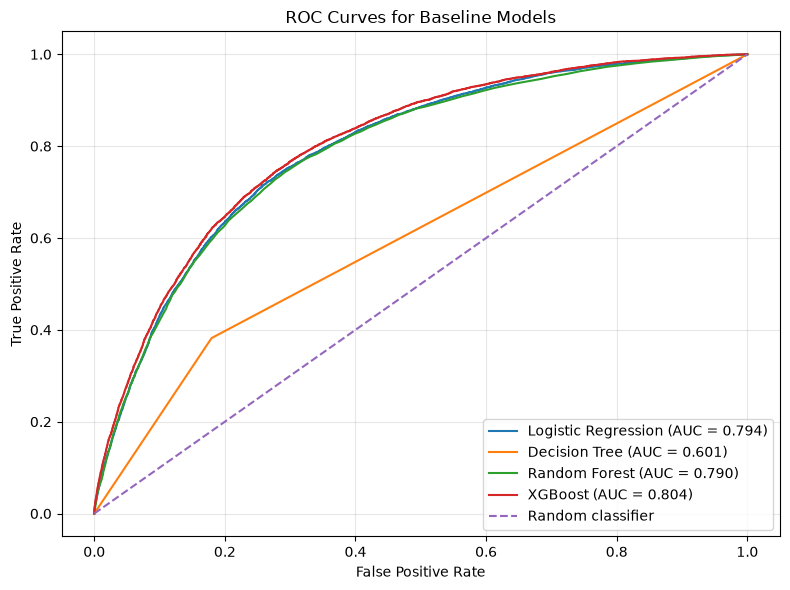

In [13]:
plt.figure(figsize=(8, 6))

for model_name, values in prediction_results.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        values["probabilities"]
    )

    model_auc = roc_auc_score(
        y_test,
        values["probabilities"]
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC = {model_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Baseline Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Compare Precision-Recall Curves

Precision-Recall curves are especially useful because Cesarean deliveries are the minority class.

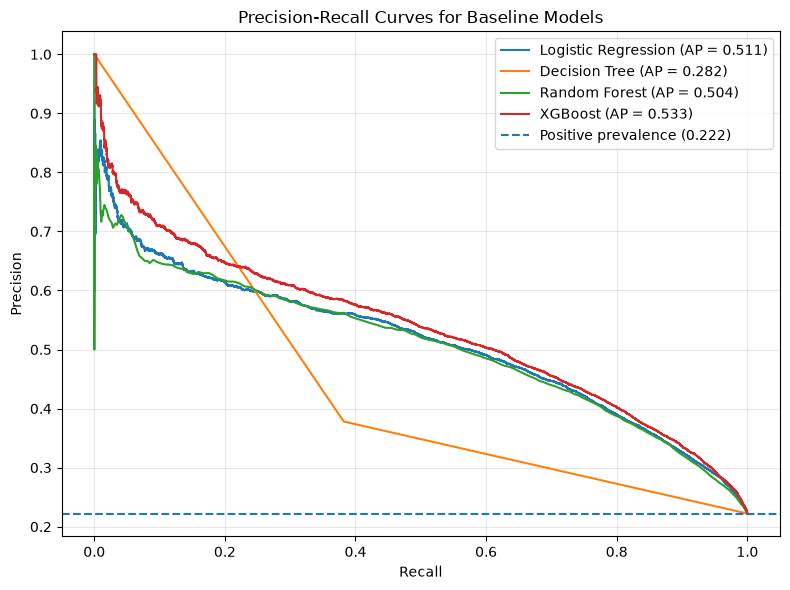

In [14]:
plt.figure(figsize=(8, 6))

for model_name, values in prediction_results.items():
    precision_values, recall_values, _ = precision_recall_curve(
        y_test,
        values["probabilities"]
    )

    model_pr_auc = average_precision_score(
        y_test,
        values["probabilities"]
    )

    plt.plot(
        recall_values,
        precision_values,
        label=f"{model_name} (AP = {model_pr_auc:.3f})"
    )

baseline_precision = y_test.mean()

plt.axhline(
    baseline_precision,
    linestyle="--",
    label=f"Positive prevalence ({baseline_precision:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for Baseline Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Save Baseline Models and Results

The fitted baseline models and performance table are saved for later tuning, comparison, and explainability.

In [15]:
model_output_path = (
    artifact_path
    / "baseline_models"
)

model_output_path.mkdir(
    parents=True,
    exist_ok=True
)

for model_name, model in fitted_models.items():
    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    joblib.dump(
        model,
        model_output_path / f"{safe_name}.joblib"
    )

results_summary.to_csv(
    model_output_path
    / "baseline_model_results.csv"
)

print("Baseline models and results saved at:")
print(model_output_path.resolve())

Baseline models and results saved at:
C:\IPD\IPD\artifacts\baseline_models


## 16. Baseline Modeling Summary

## Interpretation

Four baseline machine learning models were developed and evaluated on the held-out test set to establish a performance benchmark before hyperparameter tuning. Model performance was assessed using Accuracy, Precision, Recall, F1-score, ROC-AUC, and PR-AUC, with particular emphasis on metrics that are robust to class imbalance.

### Baseline Model Performance

| Model | ROC-AUC | PR-AUC | Recall |
|--------|--------:|-------:|-------:|
| **XGBoost** | **0.8035** | **0.5333** | **0.7479** |
| Logistic Regression | 0.7943 | 0.5109 | 0.7071 |
| Random Forest | 0.7904 | 0.5040 | 0.2846 |
| Decision Tree | 0.6012 | 0.2818 | 0.3821 |

Among the baseline models, **XGBoost achieved the highest ROC-AUC (0.8035), PR-AUC (0.5333), and Recall (74.79%)**, indicating the strongest ability to distinguish Cesarean and vaginal deliveries while effectively identifying the minority class.

### Decision Tree Performance

The Decision Tree exhibited the weakest predictive performance, with substantially lower ROC-AUC, PR-AUC, and F1-score than the other models. Its limited discriminative ability suggests that a single decision tree was unable to adequately capture the complex relationships within the dataset. Consequently, it was not considered a suitable candidate for further optimization.

### Comparison with Logistic Regression

Logistic Regression performed competitively despite being the simplest model. Although the tree-based ensemble models achieved slightly higher ROC-AUC and PR-AUC values, the improvements over Logistic Regression were relatively modest. This indicates that the selected predictor variables contain strong linear predictive information, while also benefiting from the additional flexibility provided by ensemble methods.

### Models Selected for Hyperparameter Tuning

Based on the baseline evaluation:

- **Logistic Regression** was retained as a strong and interpretable baseline model.
- **Random Forest** was selected because its relatively low Recall suggested substantial room for improvement through hyperparameter tuning.
- **XGBoost** was selected because it achieved the best overall predictive performance across nearly all evaluation metrics.

The Decision Tree was excluded from further tuning due to its substantially lower predictive performance.

These baseline results established the reference point for the subsequent hyperparameter optimization phase and guided the selection of candidate models for further development.